In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [2]:
#Import data and cheaking innear data information insides

df = pd.read_csv("Data.csv")

df.shape
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [3]:
#fill the null value in data base 

numeric_cols = df.select_dtypes(include=["number"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns



# imputer for numeric (mean or median)
num_imputer = SimpleImputer(strategy="mean")      # or "median"
cat_imputer = SimpleImputer(strategy="most_frequent")  # mode


# apply imputation
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

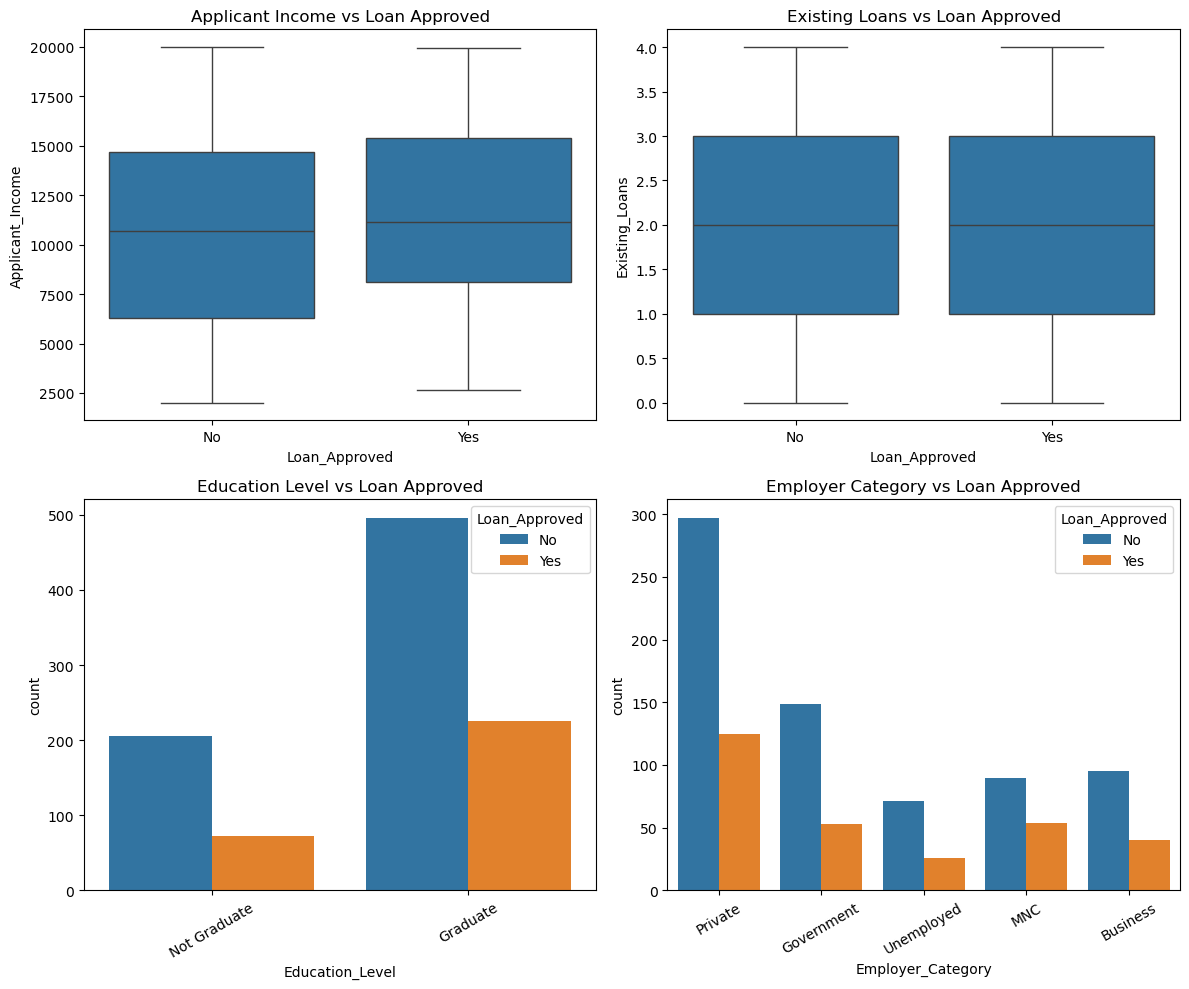

In [4]:
#EDA 
# first:- thing to cheak outlear data 
# second :-conman paten visulization data
# third :- no meinig full colums remove to data


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Applicant_Income vs Loan_Approved
sns.boxplot(x="Loan_Approved", y="Applicant_Income", data=df, ax=axes[0, 0])
axes[0, 0].set_title("Applicant Income vs Loan Approved")

# 2. Existing_Loans vs Loan_Approved
sns.boxplot(x="Loan_Approved", y="Existing_Loans", data=df, ax=axes[0, 1])
axes[0, 1].set_title("Existing Loans vs Loan Approved")

# 3. Education_Level vs Loan_Approved
sns.countplot(x="Education_Level", hue="Loan_Approved", data=df, ax=axes[1, 0])
axes[1, 0].set_title("Education Level vs Loan Approved")
axes[1, 0].tick_params(axis='x', rotation=30)

# 4. Employer_Category vs Loan_Approved
sns.countplot(x="Employer_Category", hue="Loan_Approved", data=df, ax=axes[1, 1])
axes[1, 1].set_title("Employer Category vs Loan Approved")
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64


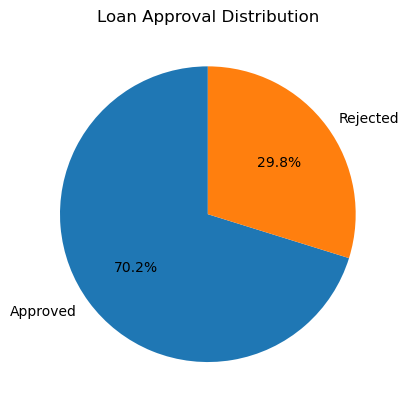

In [5]:
counts =df["Loan_Approved"].value_counts()
print(counts)

plt.pie(counts, labels=["Approved", "Rejected"], autopct="%1.1f%%", startangle=90)
plt.title("Loan Approval Distribution")
plt.show()

#Encoding data 

In [6]:
df = df.drop("Applicant_ID", axis=1)

In [7]:
le = LabelEncoder()

df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])


ohe = OneHotEncoder(sparse_output=False, drop='first')
col = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Employer_Category","Gender"]

encoded = ohe.fit_transform(df[col])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(col),
    index=df.index 
)

# # original categorical columns drop karke concat
df = pd.concat([df.drop(columns=col), encoded_df], axis=1)

# //////
cat_cols = df.select_dtypes(include="object").columns

ohe = OneHotEncoder(sparse_output=False, drop='first')

encoded = ohe.fit_transform(df[cat_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cat_cols),
    index=df.index
)

df = pd.concat([df.drop(columns=cat_cols), encoded_df], axis=1)


#Corelation cheak and after plot using Heatmap

In [8]:
num_df = df.select_dtypes(include=["number"])
corr = num_df.corr()

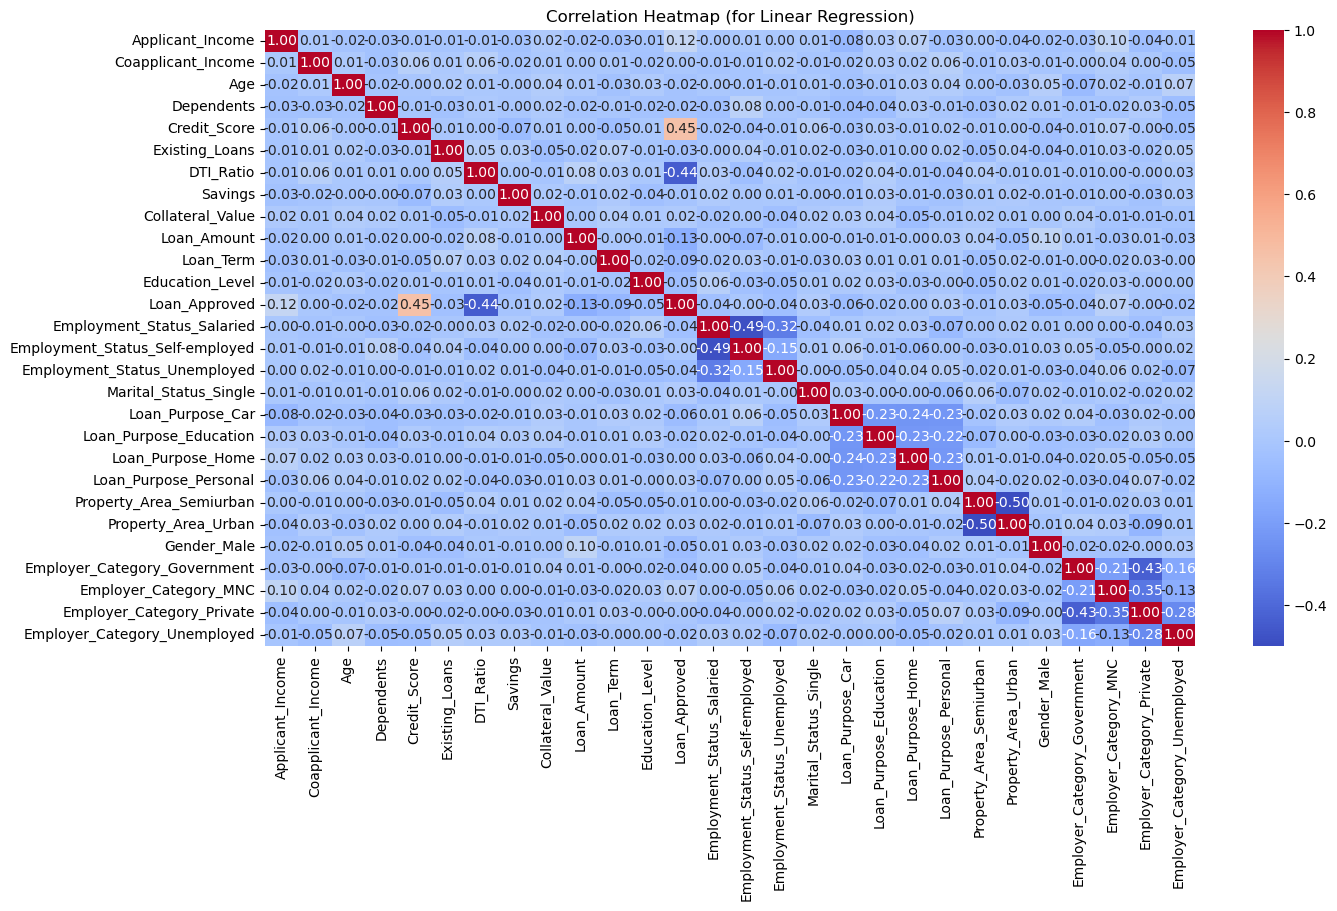

In [9]:
# corr["Loan_Approved"].sort_values(ascending=False)

plt.figure(figsize=(15,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (for Linear Regression)")
plt.show()

#Train modeal 

In [12]:
# Features & Target
X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit only on train
X_test_scaled = scaler.transform(X_test)        # transform test


#Tesating and Evolution 

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

# Model
model = LogisticRegression(max_iter=1000)

# Train
model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = model.predict(X_test_scaled)


#cheak evolution
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Evaluation - Logistic Regression")
print("Accuracy   :", acc)
print("Precision  :", prec)
print("Recall     :", rec)
print("F1 Score   :", f1)
print("Confusion Matrix:\n", cm)

Evaluation - Logistic Regression
Accuracy   : 0.865
Precision  : 0.7833333333333333
Recall     : 0.7704918032786885
F1 Score   : 0.7768595041322314
Confusion Matrix:
 [[126  13]
 [ 14  47]]


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

# Model
model = KNeighborsClassifier(n_neighbors=5)

# Train
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluation
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Evaluation - KNN")
print("Accuracy   :", acc)
print("Precision  :", prec)
print("Recall     :", rec)
print("F1 Score   :", f1)
print("Confusion Matrix:\n", cm)


Evaluation - KNN
Accuracy   : 0.76
Precision  : 0.6274509803921569
Recall     : 0.5245901639344263
F1 Score   : 0.5714285714285714
Confusion Matrix:
 [[120  19]
 [ 29  32]]


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB

# Model
model = GaussianNB()

# Train
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluation
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Evaluation - Naive Bayes")
print("Accuracy   :", acc)
print("Precision  :", prec)
print("Recall     :", rec)
print("F1 Score   :", f1)
print("Confusion Matrix:\n", cm)


Evaluation - Naive Bayes
Accuracy   : 0.865
Precision  : 0.8035714285714286
Recall     : 0.7377049180327869
F1 Score   : 0.7692307692307693
Confusion Matrix:
 [[128  11]
 [ 16  45]]
